In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from tqdm import tqdm
import matplotlib.pyplot as plt
from num2words import num2words

## Dataset

In [ ]:
DEVICE = 'mps'
BATCH_SIZE = 64

SOS = "<"
EOS = ">"
PAD = "_"
tokens = (
    [SOS, EOS, PAD]
    + [str(i) for i in range(10)]
    + [chr(ord("a") + i) for i in range(26)]
    + [" ", "-"]
)
c2i = {c: i for i, c in enumerate(tokens)}
i2c = {i: c for c, i in c2i.items()}

VOCAB_SIZE = len(tokens)

In [3]:
class Num2wordsDataset(Dataset):

    def __init__(self, test: bool = False, epoch_size: int = 1024, max_n: int = 999):
        self.test = test
        self.epoch_size = epoch_size
        self.max_n = max_n

    def __len__(self):
        return self.epoch_size

    def _generate_one(self):
        num = torch.randint(0, self.max_n + 1, (1,)).item()
        word = num2words(num)
        x = torch.tensor([c2i[c] for c in str(num)])
        y = torch.tensor([c2i[c] for c in SOS + word + EOS])
        return x, y

    def __getitem__(self, _):
        return self._generate_one()


def right_pad_seqs(batch):
    x, y = zip(*batch)
    x_lens = torch.tensor([len(s) for s in x])
    x_padded = pad_sequence(x, batch_first=True, padding_value=c2i[PAD])
    y_padded = pad_sequence(y, batch_first=True, padding_value=c2i[PAD])
    return x_padded, x_lens, y_padded


ds_train = Num2wordsDataset(test=False)
ds_test = Num2wordsDataset(test=True)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, collate_fn=right_pad_seqs)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, collate_fn=right_pad_seqs)

## Model

In [127]:

class Encoder(nn.Module):
    def __init__(self, n_layer: int, n_hidden: int, embedding_size: int = 8):
        super().__init__()
        self.embedding_size = embedding_size
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True,
        )

    def forward(self, x, x_lens) -> torch.Tensor:
        embedded = self.emb(x)
        packed = pack_padded_sequence(
            embedded,
            x_lens,
            batch_first=True,
            enforce_sorted=False,
        )
        out, (h_n, c_n) = self.lstm(packed)
        return h_n, c_n  # we want the hidden, cell state


class Decoder(nn.Module):
    def __init__(self, n_layer: int, n_hidden: int, embedding_size: int = 8):
        super().__init__()
        self.embedding_size = embedding_size
        self.emb = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embedding_size)
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True,
        )
        self.fc = nn.Linear(n_hidden, VOCAB_SIZE)

    def forward(self, x, h_n, c_n) -> torch.Tensor:
        x = x.unsqueeze(1)
        embedded = self.emb(x)
        out, (h_n, c_n) = self.lstm.forward(embedded, (h_n, c_n))
        out = self.fc(out.squeeze(1))
        return out, (h_n, c_n)


class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lens, target=None, max_len=32):
        """if trg is not None then we do teacher forcing"""
        batch_size = src.shape[0]

        h_n, c_n = self.encoder(src, src_lens)
        x = torch.full((batch_size,), c2i[SOS], dtype=src.dtype).to(self.device)

        output = []
        if target is not None:
            max_t = target.shape[-1] - 1
        else:
            max_t = max_len
        for t in range(max_t):
            out, (h_n, c_n) = self.decoder(x, h_n, c_n)
            output.append(out)

            # update next input based on teacher forcing
            if target is not None:
                x = target[:, t + 1]
            else:
                x = out.argmax(dim=-1)

        output = torch.stack(output, dim=1)
        return output

## Train ??

In [128]:
def get_test_loss(model, dl_test, teacher_forcing: bool = True):
    loss_fn = nn.CrossEntropyLoss(ignore_index=c2i[PAD])
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, x_lens, y in dl_test:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            if teacher_forcing:
                y_pred = model.forward(x, x_lens, y)
            else:
                y_pred = model.forward(x, x_lens)
            # flatten over B, T
            y_pred = y_pred.flatten(0, 1)
            y = y[:, 1:].flatten(0, 1)
            
            
            loss = loss_fn(y_pred, y)
            total_loss += loss * x.size(0)
    avg_loss = (total_loss / len(dl_test.dataset)).item()
    return avg_loss

def train(
    model: nn.Module, dl_train: DataLoader, dl_test: DataLoader, n_epochs: int = 10
):
    optim = torch.optim.AdamW(params=model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(ignore_index=c2i[PAD])
    pbar = tqdm(range(n_epochs))

    model.train()
    train_losses = []
    test_losses = []
    for _ in pbar:
        total_loss = 0
        for x, x_lens, y in dl_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optim.zero_grad()
            y_pred = model(x, x_lens, y)

            # flatten over B, T
            y_pred = y_pred.flatten(0, 1)
            y = y[:, 1:].flatten(0, 1)

            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            total_loss += loss.detach() * x.size(0)
        avg_loss = (total_loss / len(dl_train.dataset)).item()
        train_losses.append(avg_loss)
        test_loss = get_test_loss(model, dl_test)
        test_losses.append(test_loss)
        pbar.set_postfix({"Train loss": avg_loss})
    
    return train_losses, test_losses

100%|██████████| 200/200 [01:45<00:00,  1.90it/s, Train loss=0.000808]


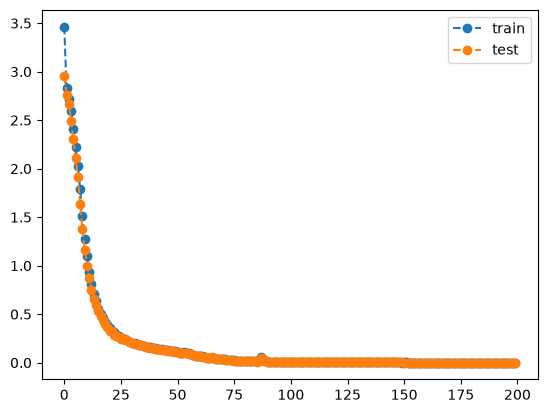

In [129]:
encoder = Encoder(2, 128).to(DEVICE)
decoder = Decoder(2, 128).to(DEVICE)
model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
train_losses, test_losses = train(model, dl_train, dl_test, n_epochs=200)
plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

In [152]:
model.eval()
for _ in range(1):
    x, y = ds_test._generate_one()
    x = x.to(DEVICE)
    y = y.to(DEVICE)
    x_len = torch.tensor([len(x)])
    y_pred = model.forward(x.unsqueeze(0), x_len).squeeze().detach().cpu()
    preds = y_pred.argmax(dim=1)
    if c2i[EOS] in preds:
        eos_idx = ((preds == c2i[EOS]) * 1).argmax()
        preds = preds[:eos_idx]
    x_str = ''.join([i2c[i.item()] for i in x])
    print(x_str + ' | ' + ''.join([i2c[i.item()] for i in preds]))

170 | one hundred and seventy
